<a href="https://colab.research.google.com/github/rcNibedita/De-Novo-Gen/blob/main/04_Chemical_Space_Analysis_and_Docking_Prioritization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4 — Exploratory Chemical-Space Analysis & Candidate Prioritization

## Purpose

Notebook 3 produced three populations:

1. **Baseline A:** unconditional MolGPT
2. **Experiment 1:** BM-scaffold seeded MolGPT
3. **Experiment 2:** fixed BM-scaffold decoration by attachment-aware substituent recombination

This notebook does **not** perform docking. It asks:

> **What chemical space did each generation strategy produce, how does it compare with the known TAK1 inhibitor space, and which candidates should be taken forward to docking?**

Novelty, similarity, and the priority score are **triage measures, not predictions of TAK1 activity**.


## Workflow

```text
Notebook 3
   ↓
quality + physicochemical properties
   ↓
novelty vs known TAK1 inhibitors
   ↓
similarity to TAK1 chemical space
   ↓
PCA chemical-space visualization
   ↓
scaffold contribution + internal diversity
   ↓
transparent candidate prioritization
   ↓
diversity-aware docking panel
   ↓
Notebook 5: TAK1 structure-guided docking
```

The separation is deliberate:

- **Notebook 3:** generate molecules
- **Notebook 4:** understand and triage molecules
- **Notebook 5:** introduce TAK1 structural/binding-site information


## 1. Install packages
Designed for Google Colab.

In [ ]:
!pip -q install rdkit pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 18.3 MB/s eta 0:00:00


In [ ]:
# Mount Google Drive

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 2. Imports and reproducibility

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Crippen, Lipinski, QED, rdMolDescriptors, AllChem
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = "/content/drive/MyDrive/De-Novo"
print("Notebook 4 ready.")


Notebook 4 ready.


## 3. Load Notebook 3 outputs

Notebook 3 writes:

- `MolGPT_baseline_unconditional.csv`
- `MolGPT_experiment1_seeded.csv`
- `MolGPT_experiment2_decorated.csv`
- `TAK1_diverse_20_BM_scaffolds.csv`

The cleaned TAK1 inhibitor dataset is also loaded because it is the reference chemical space.


In [ ]:
def require_file(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required file not found: {path}")

paths = {
    "unconditional": f"{DATA_DIR}/MolGPT_baseline_unconditional.csv",
    "seeded": f"{DATA_DIR}/MolGPT_experiment1_seeded.csv",
    "decorated": f"{DATA_DIR}/MolGPT_experiment2_decorated.csv",
    "scaffolds": f"{DATA_DIR}/TAK1_diverse_20_BM_scaffolds.csv",
    "reference": f"{DATA_DIR}/TAK1_clean_canonical.csv",
}

for p in paths.values():
    require_file(p)

df_uncond = pd.read_csv(paths["unconditional"])
df_seeded = pd.read_csv(paths["seeded"])
df_decorated = pd.read_csv(paths["decorated"])
selected_scaffolds = pd.read_csv(paths["scaffolds"])

if "df_canonical" in globals():
    tak1_df = df_canonical.copy()
else:
    tak1_df = pd.read_csv(paths["reference"])

print("Loaded:")
print("  Unconditional:", len(df_uncond))
print("  Experiment 1:", len(df_seeded))
print("  Experiment 2:", len(df_decorated))
print("  TAK1 reference:", len(tak1_df))
print("  BM seeds:", len(selected_scaffolds))


Loaded:
  Unconditional: 100
  Experiment 1: 16
  Experiment 2: 63
  TAK1 reference: 178
  BM seeds: 20


## 4. Rebuild RDKit molecules from SMILES

The CSV files may contain a `Mol` column, but RDKit molecule objects should not be relied upon after CSV export.

We therefore reconstruct molecules from the saved `SMILES` column. This makes Notebook 4 independent of Notebook 3's in-memory state.


In [ ]:
def to_mol(s):
    if not isinstance(s, str) or not s.strip():
        return None
    try:
        return Chem.MolFromSmiles(s.strip())
    except Exception:
        return None

def standardize_generated(df):
    df = df.copy()
    if "SMILES" not in df.columns:
        raise KeyError("Generated file does not contain SMILES.")
    df["Mol"] = df["SMILES"].apply(to_mol)
    df = df[df["Mol"].notna()].copy()
    df["SMILES"] = df["Mol"].apply(Chem.MolToSmiles)
    return df.drop_duplicates("SMILES").reset_index(drop=True)

def standardize_reference(df):
    df = df.copy()
    col = next((c for c in ["Canonical_SMILES", "Smiles", "SMILES"] if c in df.columns), None)
    if col is None:
        raise KeyError("Reference dataset needs Canonical_SMILES, Smiles, or SMILES.")
    df["Mol"] = df[col].apply(to_mol)
    df = df[df["Mol"].notna()].copy()
    df["SMILES"] = df["Mol"].apply(Chem.MolToSmiles)
    return df.drop_duplicates("SMILES").reset_index(drop=True)

df_uncond = standardize_generated(df_uncond)
df_seeded = standardize_generated(df_seeded)
df_decorated = standardize_generated(df_decorated)
tak1_df = standardize_reference(tak1_df)

print("Validated unique molecules:")
print("Unconditional:", len(df_uncond))
print("Experiment 1:", len(df_seeded))
print("Experiment 2:", len(df_decorated))
print("TAK1 reference:", len(tak1_df))


Validated unique molecules:
Unconditional: 100
Experiment 1: 16
Experiment 2: 63
TAK1 reference: 178


# Part I — Quality and physicochemical characterization

First we characterize the three generated populations. We do **not** rank them yet.


## 5. Calculate molecular descriptors

In [ ]:
def add_descriptors(df):
    df = df.copy()
    if df.empty:
        return df
    df["MW"] = df["Mol"].apply(Descriptors.MolWt)
    df["LogP"] = df["Mol"].apply(Crippen.MolLogP)
    df["TPSA"] = df["Mol"].apply(rdMolDescriptors.CalcTPSA)
    df["HBD"] = df["Mol"].apply(Lipinski.NumHDonors)
    df["HBA"] = df["Mol"].apply(Lipinski.NumHAcceptors)
    df["RotBonds"] = df["Mol"].apply(Lipinski.NumRotatableBonds)
    df["QED"] = df["Mol"].apply(QED.qed)
    return df

df_uncond = add_descriptors(df_uncond)
df_seeded = add_descriptors(df_seeded)
df_decorated = add_descriptors(df_decorated)
tak1_df = add_descriptors(tak1_df)


## 6. Lipinski + PAINS triage

These are simple generation-stage filters, not activity predictors.

Hard criteria:
- MW ≤ 500
- LogP ≤ 5
- HBD ≤ 5
- HBA ≤ 10
- no RDKit PAINS match


In [ ]:
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_A)
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_B)
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_C)
pains = FilterCatalog(params)

def add_quality_flags(df):
    df = df.copy()
    if df.empty:
        return df
    df["LipinskiPass"] = (
        (df["MW"] <= 500) &
        (df["LogP"] <= 5) &
        (df["HBD"] <= 5) &
        (df["HBA"] <= 10)
    )
    df["PAINS"] = df["Mol"].apply(pains.HasMatch)
    df["QualityPass"] = df["LipinskiPass"] & (~df["PAINS"])
    return df

df_uncond = add_quality_flags(df_uncond)
df_seeded = add_quality_flags(df_seeded)
df_decorated = add_quality_flags(df_decorated)

quality_summary = pd.DataFrame({
    "Unconditional": [
        len(df_uncond),
        int(df_uncond["LipinskiPass"].sum()) if len(df_uncond) else 0,
        int((~df_uncond["PAINS"]).sum()) if len(df_uncond) else 0,
        int(df_uncond["QualityPass"].sum()) if len(df_uncond) else 0,
    ],
    "Experiment 1": [
        len(df_seeded),
        int(df_seeded["LipinskiPass"].sum()) if len(df_seeded) else 0,
        int((~df_seeded["PAINS"]).sum()) if len(df_seeded) else 0,
        int(df_seeded["QualityPass"].sum()) if len(df_seeded) else 0,
    ],
    "Experiment 2": [
        len(df_decorated),
        int(df_decorated["LipinskiPass"].sum()) if len(df_decorated) else 0,
        int((~df_decorated["PAINS"]).sum()) if len(df_decorated) else 0,
        int(df_decorated["QualityPass"].sum()) if len(df_decorated) else 0,
    ],
}, index=["Valid unique", "Lipinski pass", "PAINS-free", "Quality pass"]).T

display(quality_summary)


,Valid unique,Lipinski pass,PAINS-free,Quality pass
Unconditional,100,100,100,100
Experiment 1,16,16,16,16
Experiment 2,63,63,63,63


## 7. Compare physicochemical distributions

The known TAK1 inhibitor set is the reference. The plots show whether each generation strategy occupies a broadly comparable region.


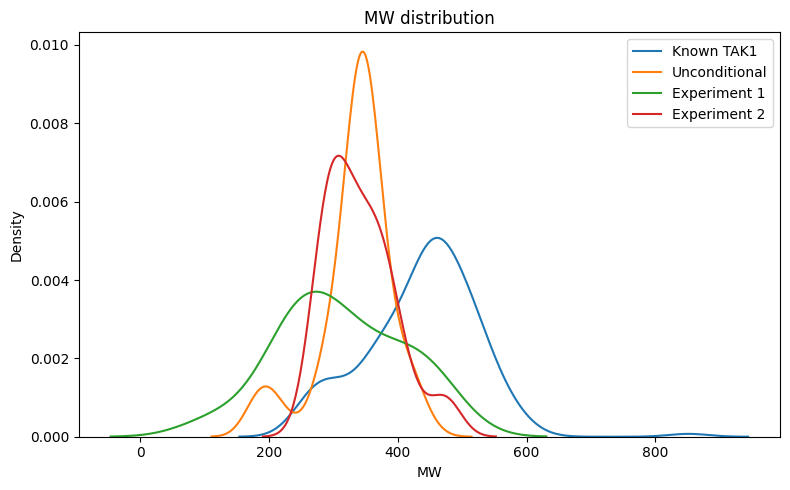

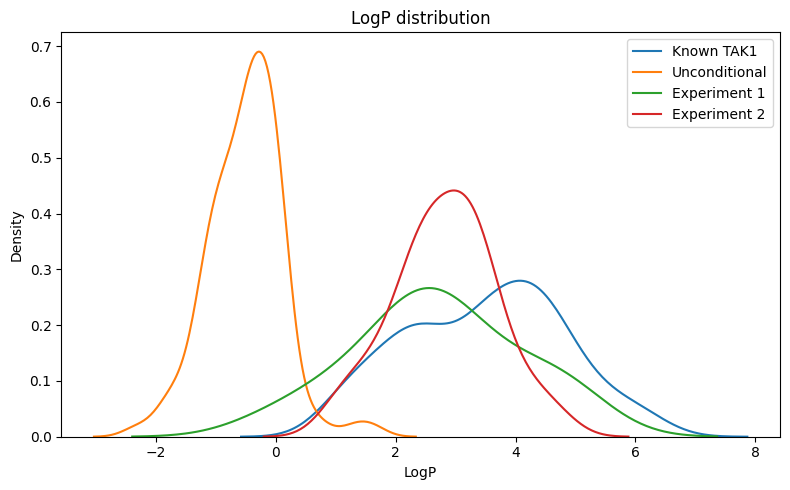

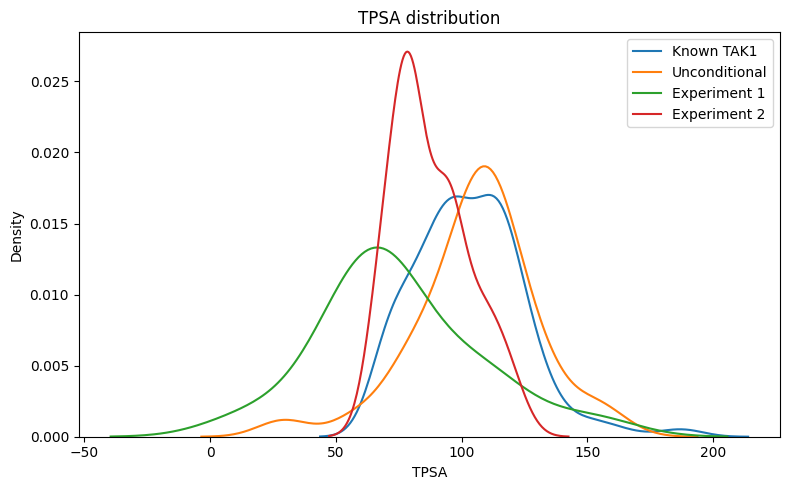

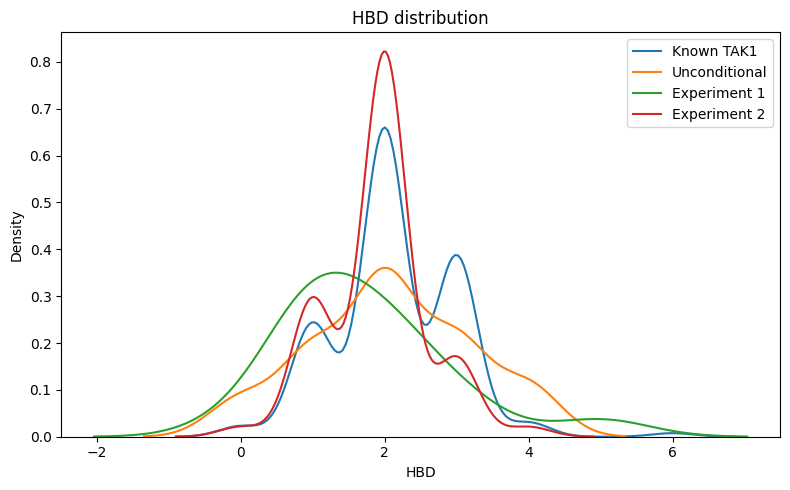

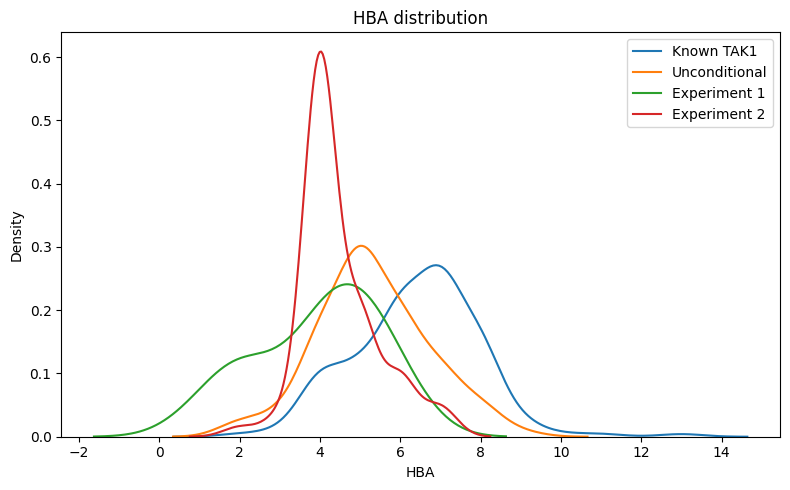

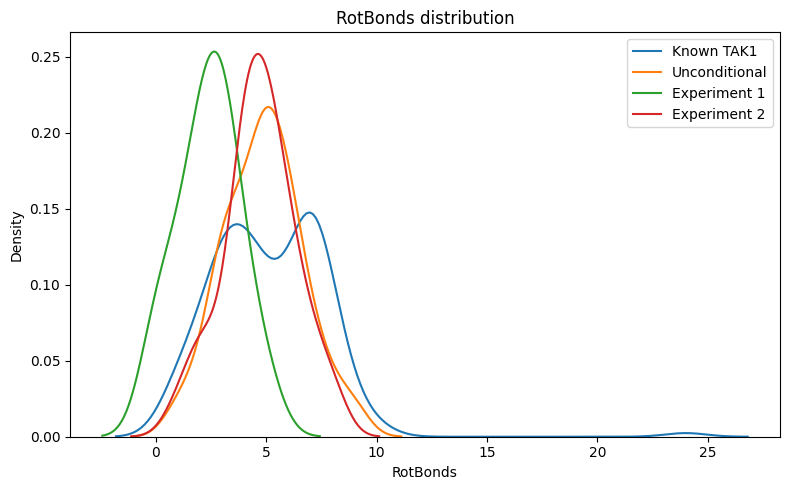

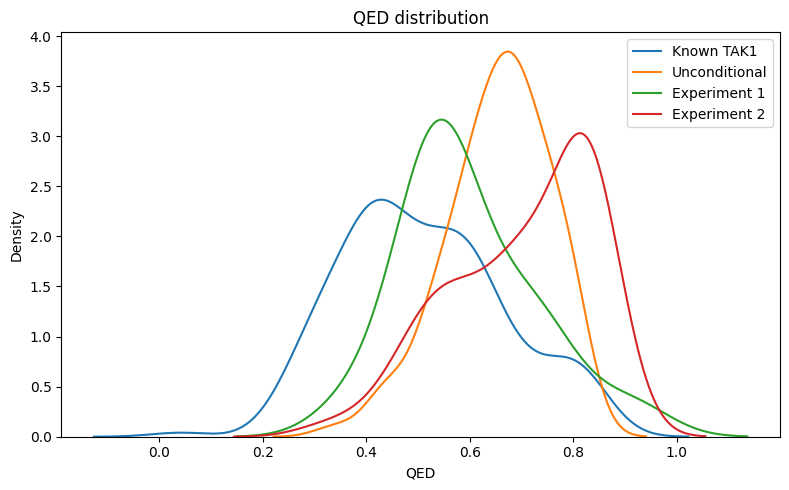

In [ ]:
populations = {
    "Known TAK1": tak1_df,
    "Unconditional": df_uncond,
    "Experiment 1": df_seeded,
    "Experiment 2": df_decorated,
}

for col in ["MW", "LogP", "TPSA", "HBD", "HBA", "RotBonds", "QED"]:
    plt.figure(figsize=(8, 5))
    for name, df in populations.items():
        if not df.empty:
            sns.kdeplot(df[col], label=name)
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.title(f"{col} distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Part II — Novelty and similarity to TAK1 chemical space

We measure two different ideas:

**Exact novelty:** is this complete molecule absent from the known TAK1 dataset?

**Chemical similarity:** how close is this molecule to at least one known TAK1 inhibitor?

A molecule can be novel while still being highly similar to known TAK1 chemistry.


## 8. Exact novelty

In [ ]:
known_smiles = set(tak1_df["SMILES"])

for df in [df_uncond, df_seeded, df_decorated]:
    if not df.empty:
        df["Novel_vs_Known_TAK1"] = ~df["SMILES"].isin(known_smiles)

novelty_summary = pd.DataFrame({
    "Unconditional": {
        "Total": len(df_uncond),
        "Novel": int(df_uncond["Novel_vs_Known_TAK1"].sum()) if len(df_uncond) else 0,
        "Novel %": 100 * df_uncond["Novel_vs_Known_TAK1"].mean() if len(df_uncond) else np.nan,
    },
    "Experiment 1": {
        "Total": len(df_seeded),
        "Novel": int(df_seeded["Novel_vs_Known_TAK1"].sum()) if len(df_seeded) else 0,
        "Novel %": 100 * df_seeded["Novel_vs_Known_TAK1"].mean() if len(df_seeded) else np.nan,
    },
    "Experiment 2": {
        "Total": len(df_decorated),
        "Novel": int(df_decorated["Novel_vs_Known_TAK1"].sum()) if len(df_decorated) else 0,
        "Novel %": 100 * df_decorated["Novel_vs_Known_TAK1"].mean() if len(df_decorated) else np.nan,
    },
}).T

display(novelty_summary.round(2))


,Total,Novel,Novel %
Unconditional,100.0,100.0,100.00
Experiment 1,16.0,16.0,100.00
Experiment 2,63.0,53.0,84.13


## 9. Maximum Tanimoto similarity to known TAK1 inhibitors

Morgan fingerprints are used to compare each generated molecule with every known TAK1 inhibitor.

For each generated molecule we retain the **maximum** Tanimoto similarity.

This is a chemical-space proximity metric, not a docking or affinity prediction.


In [ ]:
fp_gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
tak1_fps = [fp_gen.GetFingerprint(m) for m in tak1_df["Mol"]]

def max_tak1_similarity(mol):
    if mol is None or not tak1_fps:
        return np.nan
    fp = fp_gen.GetFingerprint(mol)
    return max(DataStructs.TanimotoSimilarity(fp, ref) for ref in tak1_fps)

for df in [df_uncond, df_seeded, df_decorated]:
    if not df.empty:
        df["Max_TAK1_Tanimoto"] = df["Mol"].apply(max_tak1_similarity)

similarity_summary = pd.DataFrame({
    "Unconditional": {
        "Mean": df_uncond["Max_TAK1_Tanimoto"].mean() if len(df_uncond) else np.nan,
        "Median": df_uncond["Max_TAK1_Tanimoto"].median() if len(df_uncond) else np.nan,
    },
    "Experiment 1": {
        "Mean": df_seeded["Max_TAK1_Tanimoto"].mean() if len(df_seeded) else np.nan,
        "Median": df_seeded["Max_TAK1_Tanimoto"].median() if len(df_seeded) else np.nan,
    },
    "Experiment 2": {
        "Mean": df_decorated["Max_TAK1_Tanimoto"].mean() if len(df_decorated) else np.nan,
        "Median": df_decorated["Max_TAK1_Tanimoto"].median() if len(df_decorated) else np.nan,
    },
}).T

display(similarity_summary.round(3))


,Mean,Median
Unconditional,0.194,0.197
Experiment 1,0.451,0.395
Experiment 2,0.606,0.522


## 10. Similarity distributions

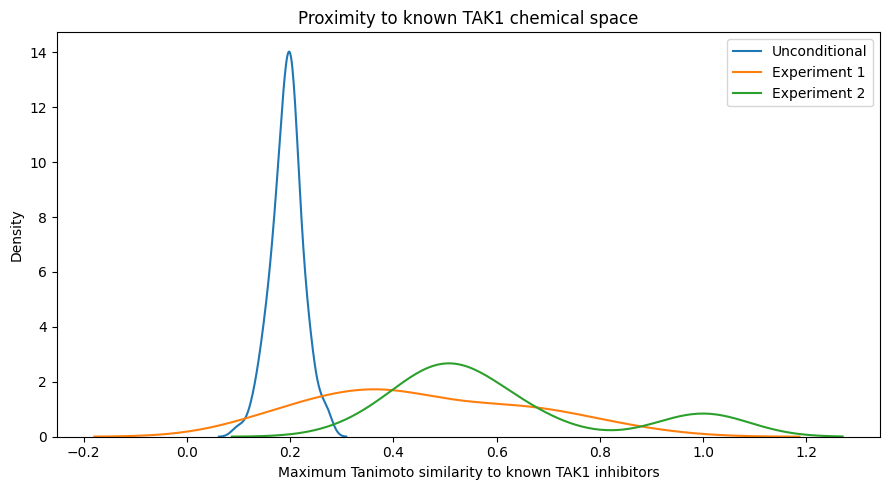

In [ ]:
plt.figure(figsize=(9, 5))
for name, df in [
    ("Unconditional", df_uncond),
    ("Experiment 1", df_seeded),
    ("Experiment 2", df_decorated),
]:
    if not df.empty:
        sns.kdeplot(df["Max_TAK1_Tanimoto"], label=name)
plt.xlabel("Maximum Tanimoto similarity to known TAK1 inhibitors")
plt.ylabel("Density")
plt.title("Proximity to known TAK1 chemical space")
plt.legend()
plt.tight_layout()
plt.show()


# Part III — Chemical-space visualization

We use Morgan fingerprints as the molecular representation and PCA as an exploratory 2-D projection.

The purpose is to visualize whether generated molecules overlap with, remain near, or expand beyond the known TAK1 inhibitor space.


PC1 explained variance: 0.091
PC2 explained variance: 0.064


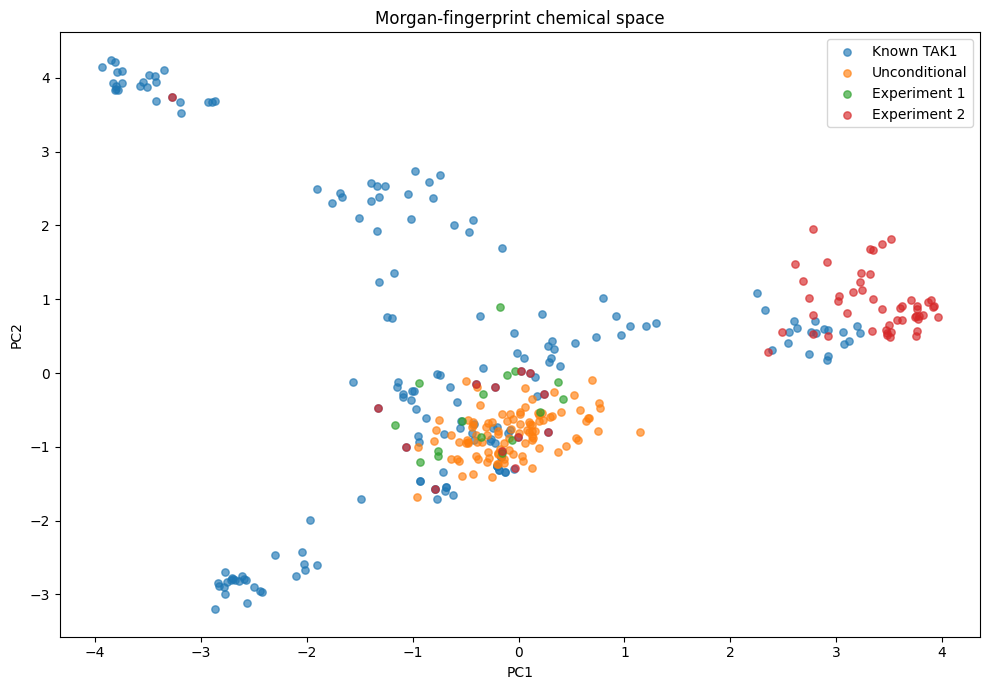

In [ ]:
frames = []
for name, df in [
    ("Known TAK1", tak1_df),
    ("Unconditional", df_uncond),
    ("Experiment 1", df_seeded),
    ("Experiment 2", df_decorated),
]:
    if not df.empty:
        x = df[["SMILES", "Mol"]].copy()
        x["Population"] = name
        frames.append(x)

space_df = pd.concat(frames, ignore_index=True)
space_fps = [fp_gen.GetFingerprint(m) for m in space_df["Mol"]]
X = np.asarray([list(fp) for fp in space_fps], dtype=float)

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X)
space_df["PC1"] = coords[:, 0]
space_df["PC2"] = coords[:, 1]

print("PC1 explained variance:", round(pca.explained_variance_ratio_[0], 3))
print("PC2 explained variance:", round(pca.explained_variance_ratio_[1], 3))

plt.figure(figsize=(10, 7))
for name in ["Known TAK1", "Unconditional", "Experiment 1", "Experiment 2"]:
    sub = space_df[space_df["Population"] == name]
    if not sub.empty:
        plt.scatter(sub["PC1"], sub["PC2"], s=28, alpha=0.65, label=name)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Morgan-fingerprint chemical space")
plt.legend()
plt.tight_layout()
plt.show()


# Part IV — Scaffold contribution and internal diversity

Experiment 1 and Experiment 2 are both related to the 20 BM seeds, but in different ways.

We inspect seed contribution so that one scaffold does not silently dominate the candidate pool.


In [ ]:
if not df_seeded.empty and "Seed_ID" in df_seeded.columns:
    if "Seed_Retained" in df_seeded.columns:
        display(
            df_seeded.groupby("Seed_ID").agg(
                Molecules=("SMILES", "count"),
                Seed_Retention=("Seed_Retained", "mean")
            ).reset_index()
        )
    else:
        display(df_seeded.groupby("Seed_ID").size().reset_index(name="Molecules"))

if not df_decorated.empty and "Seed_ID" in df_decorated.columns:
    display(
        df_decorated.groupby("Seed_ID")
        .size()
        .reset_index(name="Molecules")
    )


,Seed_ID,Molecules,Seed_Retention
0,Seed_01,1,1.0
1,Seed_02,1,1.0
2,Seed_03,1,1.0
3,Seed_04,2,1.0
4,Seed_07,1,1.0
5,Seed_08,1,1.0
6,Seed_10,1,1.0
7,Seed_11,1,1.0
8,Seed_14,1,1.0
9,Seed_15,1,1.0


,Seed_ID,Molecules
0,Seed_01,1
1,Seed_02,50
2,Seed_03,1
3,Seed_04,1
4,Seed_07,1
5,Seed_08,1
6,Seed_09,1
7,Seed_10,2
8,Seed_11,1
9,Seed_12,1


## 11. Internal diversity

We calculate:

**Internal diversity = 1 − mean pairwise Morgan Tanimoto similarity**

Higher values indicate a more structurally diverse population.

For large populations, at most 300 molecules are sampled for practicality.


In [ ]:
def internal_diversity(df, max_mols=300):
    if len(df) < 2:
        return np.nan
    work = df.sample(n=min(max_mols, len(df)), random_state=SEED)
    fps = [fp_gen.GetFingerprint(m) for m in work["Mol"]]
    sims = []
    for i in range(len(fps)):
        for j in range(i + 1, len(fps)):
            sims.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    return 1 - float(np.mean(sims)) if sims else np.nan

diversity_summary = pd.DataFrame({
    "Internal diversity": {
        "Unconditional": internal_diversity(df_uncond),
        "Experiment 1": internal_diversity(df_seeded),
        "Experiment 2": internal_diversity(df_decorated),
    }
})

display(diversity_summary.round(3))


,Internal diversity
Unconditional,0.850
Experiment 1,0.885
Experiment 2,0.661


# Part V — Candidate prioritization for docking

Now we move from exploration to triage.

The heuristic favors molecules that:
- pass basic quality filters;
- are new relative to the known TAK1 set;
- remain chemically connected to the TAK1 inhibitor space;
- have reasonable QED;
- avoid extreme MW and LogP.

**This is not a binding prediction.**

Similarity to known TAK1 chemistry is deliberately only one component.


In [ ]:
def add_priority_components(df):
    df = df.copy()
    if df.empty:
        return df

    df["Novelty_Score"] = df["Novel_vs_Known_TAK1"].astype(float)
    df["Similarity_Score"] = df["Max_TAK1_Tanimoto"].clip(0, 1)
    df["QED_Score"] = df["QED"].clip(0, 1)

    # Smooth preference for moderate properties.
    df["MW_Score"] = np.exp(-((df["MW"] - 350.0) / 150.0) ** 2)
    df["LogP_Score"] = np.exp(-((df["LogP"] - 2.5) / 2.5) ** 2)

    df["Priority_Score"] = (
        0.25 * df["Novelty_Score"] +
        0.25 * df["Similarity_Score"] +
        0.25 * df["QED_Score"] +
        0.125 * df["MW_Score"] +
        0.125 * df["LogP_Score"]
    )

    # Quality is a gate, not a reward.
    df.loc[~df["QualityPass"], "Priority_Score"] = -np.inf
    return df

df_uncond = add_priority_components(df_uncond)
df_seeded = add_priority_components(df_seeded)
df_decorated = add_priority_components(df_decorated)


## 12. Diversity-aware selection

Simply taking the top-scoring molecules could return many nearly identical analogues.

We therefore:
1. rank by priority score;
2. take the best candidate;
3. reject candidates too similar to already selected molecules;
4. continue until the requested number is reached.

Default: **10 candidates per generation category**, with a similarity cutoff of 0.80.


In [ ]:
def diversity_aware_select(df, n_select=10, similarity_cutoff=0.80):
    if df.empty:
        return df.copy()

    work = df[np.isfinite(df["Priority_Score"])].copy()
    if work.empty:
        return work

    work = work.sort_values("Priority_Score", ascending=False).reset_index(drop=True)
    selected = []
    selected_fps = []

    for idx, row in work.iterrows():
        fp = fp_gen.GetFingerprint(row["Mol"])

        if not selected_fps:
            selected.append(idx)
            selected_fps.append(fp)
        else:
            max_sim = max(
                DataStructs.TanimotoSimilarity(fp, old_fp)
                for old_fp in selected_fps
            )
            if max_sim < similarity_cutoff:
                selected.append(idx)
                selected_fps.append(fp)

        if len(selected) >= n_select:
            break

    return work.iloc[selected].reset_index(drop=True)

N_DOCKING_PER_CATEGORY = 10
DIVERSITY_CUTOFF = 0.80

priority_uncond = diversity_aware_select(df_uncond, N_DOCKING_PER_CATEGORY, DIVERSITY_CUTOFF)
priority_seeded = diversity_aware_select(df_seeded, N_DOCKING_PER_CATEGORY, DIVERSITY_CUTOFF)
priority_decorated = diversity_aware_select(df_decorated, N_DOCKING_PER_CATEGORY, DIVERSITY_CUTOFF)

print("Selected:")
print("Baseline A:", len(priority_uncond))
print("Experiment 1:", len(priority_seeded))
print("Experiment 2:", len(priority_decorated))


Selected:
Baseline A: 10
Experiment 1: 10
Experiment 2: 10


## 13. Inspect prioritized candidates

In [ ]:
base_cols = [
    "SMILES", "Priority_Score", "Novel_vs_Known_TAK1",
    "Max_TAK1_Tanimoto", "QED", "MW", "LogP", "TPSA", "HBD", "HBA"
]

print("Baseline A")
display(priority_uncond[base_cols] if not priority_uncond.empty else pd.DataFrame())

print("Experiment 1")
display(
    priority_seeded[["Seed_ID", "Seed_Scaffold"] + base_cols]
    if not priority_seeded.empty else pd.DataFrame()
)

print("Experiment 2")
extra = [c for c in ["Seed_ID", "Seed_Scaffold", "Fragment_SMILES"] if c in priority_decorated.columns]
display(
    priority_decorated[extra + base_cols]
    if not priority_decorated.empty else pd.DataFrame()
)


Baseline A


,SMILES,Priority_Score,Novel_vs_Known_TAK1,Max_TAK1_Tanimoto,QED,MW,LogP,TPSA,HBD,HBA
0,C[C@H]1CN(C)C[C@H]1C(=O)NC1CN(C(=O)c2cnn(CCF)c...,0.675459,True,0.202247,0.820501,337.399,-0.00910,70.47,1,4
1,Cn1ncc(C(=O)N2C[C@H]3C[C@H](NC(=O)c4ncc[nH]4)C...,0.669049,True,0.186047,0.821233,329.364,-0.03870,108.80,2,5
2,CN(C)C(=O)CN1CC[C@@H]2CCN(C(=O)c3cnn(C)c3N)C[C...,0.667738,True,0.228261,0.814587,334.424,-0.37310,87.70,1,5
3,COc1cc(C(=O)N2CCN(C(=O)[C@@H]3CCN(C)C3)CC2)nn1C,0.665287,True,0.271605,0.756086,335.408,-0.33520,70.91,0,5
4,O=C(Cn1cccn1)N[C@@H]1CCN(C(=O)c2cc(Cl)no2)C[C@...,0.664408,True,0.191919,0.794193,353.766,-0.08370,113.49,2,6
5,CC(C)[C@@H](CNC(=O)c1ncn(C)n1)NC(=O)c1cnn2c1OCCC2,0.664091,True,0.231579,0.746878,361.406,-0.02150,115.96,2,6
6,Cc1cc(CN[C@H]2C[C@@H](NC(=O)c3nnn(C)n3)C23CCC3...,0.663114,True,0.160377,0.796447,344.423,0.08282,102.55,2,6
7,O=C(N[C@@H]1CN(C(=O)[C@H]2CCCO2)C[C@@H]1O)c1cc...,0.659319,True,0.218750,0.728850,344.371,0.04340,107.55,3,5
8,Cc1ncn(C)c1C(=O)N1C[C@H](O)[C@H](NC(=O)c2cc(F)...,0.656434,True,0.250000,0.723259,335.339,-0.18898,103.25,3,4
9,Cn1cc(CC(=O)N[C@]23CCC[C@H]2CN(C(=O)[C@@]2(C)C...,0.656177,True,0.179245,0.775643,373.457,-0.01390,96.33,2,4


Experiment 1


,Seed_ID,Seed_Scaffold,SMILES,Priority_Score,Novel_vs_Known_TAK1,Max_TAK1_Tanimoto,QED,MW,LogP,TPSA,HBD,HBA
0,Seed_08,c1cc2[nH]ncc2cc1-c1cnc2ccc(N3C[C@@H]4C[C@H]3CO...,c1cc2[nH]ncc2cc1-c1cnc2ccc(N3C[C@@H]4C[C@H]3CO...,0.825199,True,0.703125,0.609504,332.367,2.2501,71.34,1,5
1,Seed_07,O=C1Nc2ccccc2OC[C@@H]1N1CCc2cn(CC3CCS(=O)(=O)C...,O=C1Nc2ccccc2OC[C@@H]1N1CCc2cn(CC3CCS(=O)(=O)C...,0.791513,True,0.704225,0.759293,444.513,1.1059,110.60,1,6
2,Seed_11,O=C(Nc1ccc(C(=O)N2CCNCC2)cc1C1CCCCC1)c1csc2c(=...,O=C(Nc1ccc(C(=O)N2CCNCC2)cc1C1CCCCC1)c1csc2c(=...,0.778114,True,0.840580,0.547923,465.579,3.3300,107.19,3,6
3,Seed_10,O=C(Nc1cccc(-c2nnc[nH]2)n1)Nc1nccc2ccccc12,O=C(Nc1cccc(-c2nnc[nH]2)n1)Nc1nccc2ccccc12,0.777239,True,0.606557,0.534454,331.339,3.0589,108.48,3,5
4,Seed_03,c1csc(-c2ccc(CN3CCNCC3)cc2)c1,c1csc(-c2ccc(CN3CCNCC3)cc2)c1,0.764792,True,0.312500,0.910475,258.390,2.8203,15.27,1,3
5,Seed_14,O=c1[nH]nc2ccc3ccc(-c4ccc[nH]4)cc3n12,O=c1[nH]nc2ccc3ccc(-c4ccc[nH]4)cc3n12,0.745903,True,0.627451,0.543415,250.261,2.1709,65.95,2,2
6,Seed_20,c1ccc(Oc2ccnc(Nc3cn[nH]c3)n2)cc1,c1ccc(Oc2ccnc(Nc3cn[nH]c3)n2)cc1,0.723044,True,0.319444,0.747277,253.265,2.7356,75.72,2,5
7,Seed_04,O=C(N=c1[nH]c2ccccc2[nH]1)c1ccccc1,O=C(N=c1[nH]c2ccccc2[nH]1)c1ccccc1,0.707060,True,0.380000,0.669526,237.262,2.2371,61.01,2,1
8,Seed_19,c1c[nH]c(-c2ncc(-c3c[nH]c4ccccc34)o2)c1,c1c[nH]c(-c2ncc(-c3c[nH]c4ccccc34)o2)c1,0.704952,True,0.555556,0.567064,249.273,3.8180,57.61,2,2
9,Seed_18,c1ccc(Nc2ccn3nccc3n2)nc1,c1ccc(Nc2ccn3nccc3n2)nc1,0.689310,True,0.373134,0.702620,211.228,1.8679,55.11,1,4


Experiment 2


,Seed_ID,Seed_Scaffold,Fragment_SMILES,SMILES,Priority_Score,Novel_vs_Known_TAK1,Max_TAK1_Tanimoto,QED,MW,LogP,TPSA,HBD,HBA
0,Seed_02,c1ncc2cc[nH]c2n1,R1=C[*:1] | R2=O=C(/C=C/[*:2])NC1CC1 | R3=CC(C...,Cc1[nH]c2ncnc(OCC(C)C)c2c1C=CC(=O)NC1CC1,0.863272,True,0.677966,0.803212,314.389,2.59292,79.90,2,4
1,Seed_02,c1ncc2cc[nH]c2n1,R1=C[*:1] | R2=NC(=O)/C(Cl)=C/[*:2] | R3=CC(C)...,Cc1[nH]c2ncnc(OCC(C)C)c2c1C=C(Cl)C(N)=O,0.859850,True,0.648148,0.829068,308.769,2.36612,93.89,2,4
2,Seed_02,c1ncc2cc[nH]c2n1,R1=C[*:1] | R2=O=C(/C=C/[*:2])NCC1CC1 | R3=CC(...,Cc1[nH]c2ncnc(OCC(C)C)c2c1C=CC(=O)NCC1CC1,0.858775,True,0.688525,0.766011,328.416,2.84052,79.90,2,4
3,Seed_02,c1ncc2cc[nH]c2n1,R1=C[*:1] | R2=NC(=O)/C=C/[*:2] | R3=CC(C)(C)C...,Cc1[nH]c2ncnc(OCC(C)(C)C)c2c1C=CC(N)=O,0.848097,True,0.634615,0.843126,288.351,2.18972,93.89,2,4
4,Seed_02,c1ncc2cc[nH]c2n1,R1=C[*:1] | R2=CNC(=O)/C=C/[*:2] | R3=FC1(F)CC...,CNC(=O)C=Cc1c(C)[nH]c2ncnc(OC3CCC(F)(F)CC3)c12,0.839907,True,0.546875,0.831019,350.369,2.98222,79.90,2,4
5,Seed_02,c1ncc2cc[nH]c2n1,R1=C[*:1] | R2=CCC(=O)/C=C/[*:2] | R3=CC(C)CO[...,CCC(=O)C=Cc1c(C)[nH]c2ncnc(OCC(C)C)c12,0.835327,True,0.641509,0.827716,287.363,3.29342,67.87,1,4
6,Seed_02,c1ncc2cc[nH]c2n1,R1=C[*:1] | R2=CN(C)C(=O)/C=C/[*:2] | R3=CCC(C...,CCC(C)Oc1ncnc2[nH]c(C)c(C=CC(=O)N(C)C)c12,0.832547,True,0.516667,0.861622,302.378,2.54502,71.11,1,4
7,Seed_02,c1ncc2cc[nH]c2n1,R1=C[*:1] | R2=NC(=O)C#C[*:2] | R3=FC1(F)CCC(O...,Cc1[nH]c2ncnc(OC3CCC(F)(F)CC3)c2c1C#CC(N)=O,0.829264,True,0.515625,0.822125,334.326,2.05982,93.89,2,4
8,Seed_02,c1ncc2cc[nH]c2n1,R1=C[*:1] | R2=CNC(=O)/C=C/[*:2] | R3=CC(C)(C)...,CNC(=O)C=Cc1c(C)[nH]c2ncnc(OCC(C)(C)C)c12,0.825514,True,0.500000,0.850191,302.378,2.45042,79.90,2,4
9,Seed_02,c1ncc2cc[nH]c2n1,R1=C[*:1] | R2=NC(=O)/C(Cl)=C/[*:2] | R3=FC(F)...,Cc1[nH]c2ncnc(OCC(F)(F)F)c2c1C=C(Cl)C(N)=O,0.823993,True,0.466667,0.838619,334.685,2.27242,93.89,2,4


# Part VI — Final docking-ready candidate set

We combine the three categories while preserving provenance.

Default target:
- 10 unconditional
- 10 seeded
- 10 decorated

If a category cannot provide enough quality-passing and sufficiently diverse molecules, fewer are retained.


In [ ]:
def tag(df, category):
    x = df.copy()
    x["Generation_Category"] = category
    return x

docking_candidates = pd.concat([
    tag(priority_uncond, "Baseline_A_Unconditional"),
    tag(priority_seeded, "Experiment_1_Seeded"),
    tag(priority_decorated, "Experiment_2_Decorated"),
], ignore_index=True)

docking_candidates.insert(
    0, "Candidate_ID",
    [f"Dock_{i+1:03d}" for i in range(len(docking_candidates))]
)

docking_candidates = docking_candidates.sort_values(
    ["Generation_Category", "Priority_Score"],
    ascending=[True, False]
).reset_index(drop=True)

display(docking_candidates[[
    "Candidate_ID", "Generation_Category", "SMILES",
    "Priority_Score", "Novel_vs_Known_TAK1",
    "Max_TAK1_Tanimoto", "QED", "MW", "LogP"
]])


,Candidate_ID,Generation_Category,SMILES,Priority_Score,Novel_vs_Known_TAK1,Max_TAK1_Tanimoto,QED,MW,LogP
0,Dock_001,Baseline_A_Unconditional,C[C@H]1CN(C)C[C@H]1C(=O)NC1CN(C(=O)c2cnn(CCF)c...,0.675459,True,0.202247,0.820501,337.399,-0.00910
1,Dock_002,Baseline_A_Unconditional,Cn1ncc(C(=O)N2C[C@H]3C[C@H](NC(=O)c4ncc[nH]4)C...,0.669049,True,0.186047,0.821233,329.364,-0.03870
2,Dock_003,Baseline_A_Unconditional,CN(C)C(=O)CN1CC[C@@H]2CCN(C(=O)c3cnn(C)c3N)C[C...,0.667738,True,0.228261,0.814587,334.424,-0.37310
3,Dock_004,Baseline_A_Unconditional,COc1cc(C(=O)N2CCN(C(=O)[C@@H]3CCN(C)C3)CC2)nn1C,0.665287,True,0.271605,0.756086,335.408,-0.33520
4,Dock_005,Baseline_A_Unconditional,O=C(Cn1cccn1)N[C@@H]1CCN(C(=O)c2cc(Cl)no2)C[C@...,0.664408,True,0.191919,0.794193,353.766,-0.08370
5,Dock_006,Baseline_A_Unconditional,CC(C)[C@@H](CNC(=O)c1ncn(C)n1)NC(=O)c1cnn2c1OCCC2,0.664091,True,0.231579,0.746878,361.406,-0.02150
6,Dock_007,Baseline_A_Unconditional,Cc1cc(CN[C@H]2C[C@@H](NC(=O)c3nnn(C)n3)C23CCC3...,0.663114,True,0.160377,0.796447,344.423,0.08282
7,Dock_008,Baseline_A_Unconditional,O=C(N[C@@H]1CN(C(=O)[C@H]2CCCO2)C[C@@H]1O)c1cc...,0.659319,True,0.218750,0.728850,344.371,0.04340
8,Dock_009,Baseline_A_Unconditional,Cc1ncn(C)c1C(=O)N1C[C@H](O)[C@H](NC(=O)c2cc(F)...,0.656434,True,0.250000,0.723259,335.339,-0.18898
9,Dock_010,Baseline_A_Unconditional,Cn1cc(CC(=O)N[C@]23CCC[C@H]2CN(C(=O)[C@@]2(C)C...,0.656177,True,0.179245,0.775643,373.457,-0.01390


## 14. Save outputs

The notebook writes:

1. **`Notebook4_all_generated_with_analysis.csv`** — all generated molecules with descriptors, novelty, similarity, quality, and priority components.
2. **`Notebook4_docking_candidates.csv`** — the final diversity-aware docking panel.
3. **`Notebook4_population_summary.csv`** — compact comparison of the three generation strategies.


In [ ]:
all_frames = []
for category, df in [
    ("Baseline_A_Unconditional", df_uncond),
    ("Experiment_1_Seeded", df_seeded),
    ("Experiment_2_Decorated", df_decorated),
]:
    if not df.empty:
        x = df.copy()
        x["Generation_Category"] = category
        all_frames.append(x)

all_generated_df = pd.concat(all_frames, ignore_index=True) if all_frames else pd.DataFrame()

population_summary = pd.DataFrame({
    "Baseline_A_Unconditional": {
        "Valid unique": len(df_uncond),
        "Quality pass": int(df_uncond["QualityPass"].sum()) if len(df_uncond) else 0,
        "Exact novel": int(df_uncond["Novel_vs_Known_TAK1"].sum()) if len(df_uncond) else 0,
        "Mean max TAK1 similarity": df_uncond["Max_TAK1_Tanimoto"].mean() if len(df_uncond) else np.nan,
        "Mean QED": df_uncond["QED"].mean() if len(df_uncond) else np.nan,
        "Internal diversity": internal_diversity(df_uncond),
    },
    "Experiment_1_Seeded": {
        "Valid unique": len(df_seeded),
        "Quality pass": int(df_seeded["QualityPass"].sum()) if len(df_seeded) else 0,
        "Exact novel": int(df_seeded["Novel_vs_Known_TAK1"].sum()) if len(df_seeded) else 0,
        "Mean max TAK1 similarity": df_seeded["Max_TAK1_Tanimoto"].mean() if len(df_seeded) else np.nan,
        "Mean QED": df_seeded["QED"].mean() if len(df_seeded) else np.nan,
        "Internal diversity": internal_diversity(df_seeded),
    },
    "Experiment_2_Decorated": {
        "Valid unique": len(df_decorated),
        "Quality pass": int(df_decorated["QualityPass"].sum()) if len(df_decorated) else 0,
        "Exact novel": int(df_decorated["Novel_vs_Known_TAK1"].sum()) if len(df_decorated) else 0,
        "Mean max TAK1 similarity": df_decorated["Max_TAK1_Tanimoto"].mean() if len(df_decorated) else np.nan,
        "Mean QED": df_decorated["QED"].mean() if len(df_decorated) else np.nan,
        "Internal diversity": internal_diversity(df_decorated),
    }
}).T

all_generated_df.to_csv("/content/drive/MyDrive/De-Novo/Notebook4_all_generated_with_analysis.csv", index=False)
docking_candidates.to_csv("/content/drive/MyDrive/De-Novo/Notebook4_docking_candidates.csv", index=False)
population_summary.to_csv("/content/drive/MyDrive/De-Novo/Notebook4_population_summary.csv", index=True)

print("Saved:")
print("Notebook4_all_generated_with_analysis.csv")
print("Notebook4_docking_candidates.csv")
print("Notebook4_population_summary.csv")


Saved:
Notebook4_all_generated_with_analysis.csv
Notebook4_docking_candidates.csv
Notebook4_population_summary.csv


# Interpretation and hand-off to Notebook 5

### Notebook 3 — Generation
Can we generate molecules using three different strategies?

### Notebook 4 — Exploration and triage
What chemical space did those strategies produce, and which molecules are sufficiently novel, chemically connected to TAK1 inhibitor space, drug-like, and diverse enough to evaluate?

### Notebook 5 — Structure-guided evaluation
Only now do we introduce:
- the TAK1 protein structure;
- binding-pocket definition;
- protein preparation;
- ligand preparation;
- docking;
- binding-pose and interaction analysis.

**No Notebook 4 score is evidence of TAK1 activity.**
